In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv
/kaggle/input/datasets/ladkevinkumar/group9-dsb/swift_currency_tracker_all_reports.csv


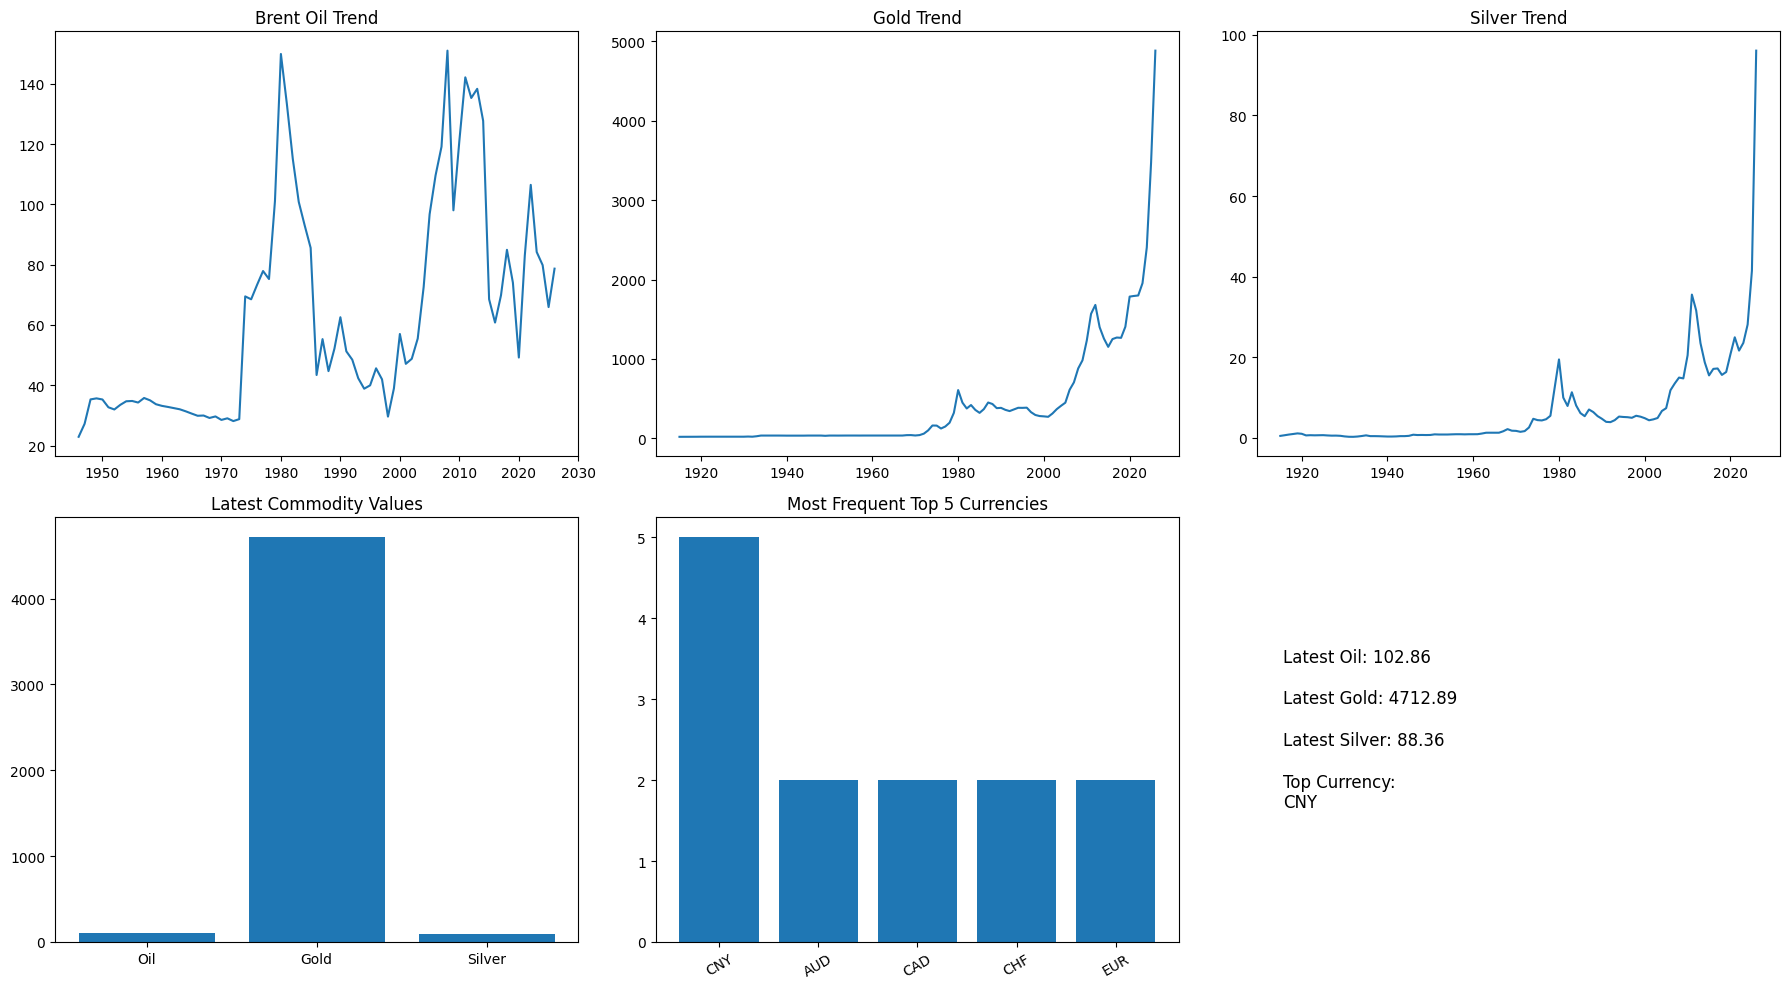

                      Indicator    Value
0              Latest Brent Oil   102.86
1                   Latest Gold  4712.89
2                 Latest Silver    88.36
3  Most Frequent Top-5 Currency      CNY


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

oil_df = pd.read_csv('/kaggle/input/datasets/ladkevinkumar/group9-dsb/Brent Oil.csv')
gold_df = pd.read_csv('/kaggle/input/datasets/ladkevinkumar/group9-dsb/Gold 100years.csv')
silver_df = pd.read_csv('/kaggle/input/datasets/ladkevinkumar/group9-dsb/silver 100 years.csv')
swift_df = pd.read_csv('/kaggle/input/datasets/ladkevinkumar/group9-dsb/swift_currency_tracker_all_reports.csv')

oil_df['Date'] = pd.to_datetime(oil_df['Date'], dayfirst=True)
gold_df['Date'] = pd.to_datetime(gold_df['Date'], dayfirst=True)
silver_df['Date'] = pd.to_datetime(silver_df['Date'], dayfirst=True)

oil_df['Year'] = oil_df['Date'].dt.year
gold_df['Year'] = gold_df['Date'].dt.year
silver_df['Year'] = silver_df['Date'].dt.year

oil_year = oil_df.groupby('Year')['Value'].mean().reset_index()
gold_year = gold_df.groupby('Year')['Value'].mean().reset_index()
silver_year = silver_df.groupby('Year')['Value'].mean().reset_index()

latest_oil = oil_df.sort_values('Date').iloc[-1]['Value']
latest_gold = gold_df.sort_values('Date').iloc[-1]['Value']
latest_silver = silver_df.sort_values('Date').iloc[-1]['Value']

swift_df['rmb_global_rank'] = pd.to_numeric(
    swift_df['rmb_global_rank'],
    errors='coerce'
)

top5 = (
    swift_df[swift_df['rmb_global_rank'] <= 5]
    .groupby('currency_or_economy')
    .size()
    .sort_values(ascending=False)
    .head(5)
)

fig, ax = plt.subplots(2, 3, figsize=(18, 10))

ax[0,0].plot(oil_year['Year'], oil_year['Value'])
ax[0,0].set_title('Brent Oil Trend')

ax[0,1].plot(gold_year['Year'], gold_year['Value'])
ax[0,1].set_title('Gold Trend')

ax[0,2].plot(silver_year['Year'], silver_year['Value'])
ax[0,2].set_title('Silver Trend')

ax[1,0].bar(
    ['Oil','Gold','Silver'],
    [latest_oil, latest_gold, latest_silver]
)
ax[1,0].set_title('Latest Commodity Values')

ax[1,1].bar(
    top5.index.astype(str),
    top5.values
)
ax[1,1].set_title('Most Frequent Top 5 Currencies')
ax[1,1].tick_params(axis='x', rotation=30)

ax[1,2].axis('off')
summary = (
    f"Latest Oil: {latest_oil:.2f}\n\n"
    f"Latest Gold: {latest_gold:.2f}\n\n"
    f"Latest Silver: {latest_silver:.2f}\n\n"
    f"Top Currency:\n{top5.index[0]}"
)
ax[1,2].text(
    0.05,
    0.5,
    summary,
    fontsize=12,
    va='center'
)

plt.tight_layout()

plt.savefig(
    'dashboard_summary.pdf',
    bbox_inches='tight'
)

plt.show()

dashboard_table = pd.DataFrame({
    'Indicator': [
        'Latest Brent Oil',
        'Latest Gold',
        'Latest Silver',
        'Most Frequent Top-5 Currency'
    ],
    'Value': [
        round(latest_oil,2),
        round(latest_gold,2),
        round(latest_silver,2),
        top5.index[0]
    ]
})

dashboard_table.to_csv(
    'dashboard_summary_table.csv',
    index=False
)

print(dashboard_table)